<a href="https://colab.research.google.com/github/Nicossm/parcial1/blob/main/Notebooks/Notebook_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FASE 1 - Limpieza y Preparación de Datos

En esta sección se trabaja sobre el dataset crudo, realizando un proceso de limpieza y estandarización para asegurar la calidad de los datos.

Se incluyen las siguientes tareas:

- Manejo de valores nulos (NaN)
- Eliminación de registros duplicados
- Normalización de variables categóricas (ej. country, education)
- Tratamiento de valores inconsistentes
- Detección y tratamiento de outliers
- Generación de un dataset limpio para su uso en etapas posteriores


## 1.1 Importación de Librerías y Carga de Datos

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('https://raw.githubusercontent.com/Nicossm/parcial1/main/data/raw/software_developer_salary_raw.csv')

# 1. Análisis Exploratorio Inicial (EDA)

In [15]:
# Vista inicial de los datos
df.head()

,experience,country,education,languages,frameworks,company_size,salary_usd
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189
1,38,France,Masters,"Ruby, Python",NaN,201-1000,147754
2,36,USA,Some College,"PHP, C++","Spring, Ruby on Rails",5000+,220819
3,3,India,masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943
4,18,USA,Masters,"Go, Java","React, Django",5000+,166442


In [16]:
# Informacion general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   experience    9676 non-null   object
 1   country       10300 non-null  object
 2   education     9474 non-null   object
 3   languages     9467 non-null   object
 4   frameworks    9477 non-null   object
 5   company_size  10300 non-null  object
 6   salary_usd    9670 non-null   object
dtypes: object(7)
memory usage: 563.4+ KB


In [17]:
# Count: valores no nulos
# unique: cant valores unicos
# top: moda
# freq: cant del valor en top
display(df.describe())

,experience,country,education,languages,frameworks,company_size,salary_usd
count,9676,10300,9474,9467,9477,10300,9670
unique,79,55,30,100,100,6,9091
top,32,USA,Bachelors,"Rust, Ruby","Angular, Express",11-50,missing
freq,270,3910,4572,123,118,1786,25


## 1.3 Detección de Valores Nulos (NaN)

In [18]:
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna)

experience      624
country           0
education       826
languages       833
frameworks      823
company_size      0
salary_usd      630
dtype: int64


In [19]:
# Porcentaje de nulos para decidir si imputar o eliminar
print("\n--- Porcentaje de Valores Nulos ---")
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print(porcentaje_nulos[porcentaje_nulos > 0].round(2).astype(str) + '%')


--- Porcentaje de Valores Nulos ---
experience    6.06%
education     8.02%
languages     8.09%
frameworks    7.99%
salary_usd    6.12%
dtype: object


## 1.4 Detección de Duplicados

In [20]:
total_duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {total_duplicados}")

Total de filas duplicadas: 211


In [21]:
if total_duplicados > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(4))

,experience,country,education,languages,frameworks,company_size,salary_usd
879,0,Canada,Masters,"PHP, Java","React, Express",1001-5000,61172
5799,0,Canada,Masters,"PHP, Java","React, Express",1001-5000,61172
1891,0,Canada,Some College,"C#, Rust","Spring, ASP.NET",1-10,61344
9792,0,Canada,Some College,"C#, Rust","Spring, ASP.NET",1-10,61344


## 1.5 Detección de Outliers


In [22]:
def detectar_outliers_iqr(df, columna):
    # Forzar numérico por si hay tipos mezclados
    temp_series = pd.to_numeric(df[columna], errors='coerce')

    Q1 = temp_series.quantile(0.25)
    Q3 = temp_series.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = temp_series[(temp_series < limite_inferior) | (temp_series > limite_superior)]

    print(f"--- Análisis Outliers: {columna} ---")
    print(f"Límite Inferior: {limite_inferior:.2f}")
    print(f"Límite Superior: {limite_superior:.2f}")
    print(f"Cantidad de Outliers detectados: {len(outliers)}\n")

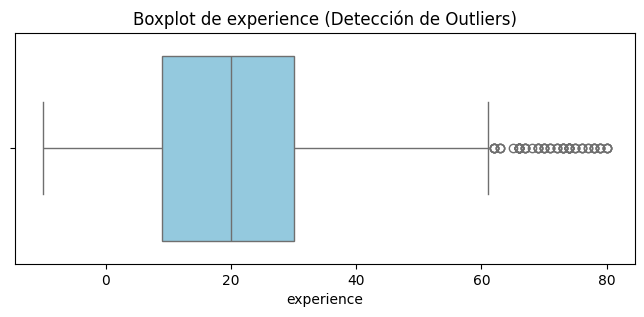

--- Análisis Outliers: experience ---
Límite Inferior: -22.50
Límite Superior: 61.50
Cantidad de Outliers detectados: 73



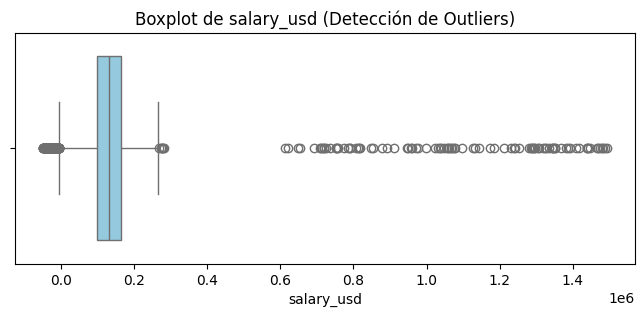

--- Análisis Outliers: salary_usd ---
Límite Inferior: -5204.25
Límite Superior: 266737.75
Cantidad de Outliers detectados: 184



In [23]:
columnas_numericas = ['experience', 'salary_usd']
for col in columnas_numericas:
    # Boxplot
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=pd.to_numeric(df[col], errors='coerce'), color='skyblue')
    plt.title(f'Boxplot de {col} (Detección de Outliers)')
    plt.show()

    # Cálculos IQR
    detectar_outliers_iqr(df, col)

## 1.6 Visualizaciones Iniciales (Distribuciones y Relaciones)

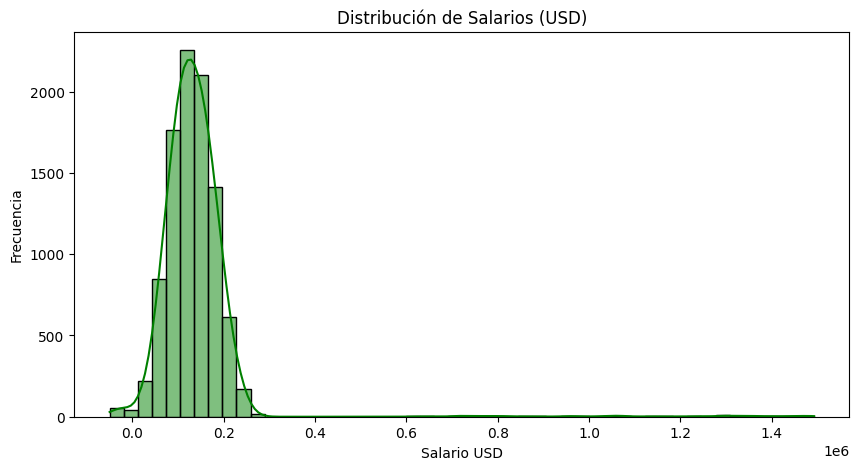

In [24]:
# 1. Distribución de la variable salary_usd
plt.figure(figsize=(10, 5))
sns.histplot(pd.to_numeric(df['salary_usd'], errors='coerce'), bins=50, kde=True, color='green')
plt.title('Distribución de Salarios (USD)')
plt.xlabel('Salario USD')
plt.ylabel('Frecuencia')
plt.show()


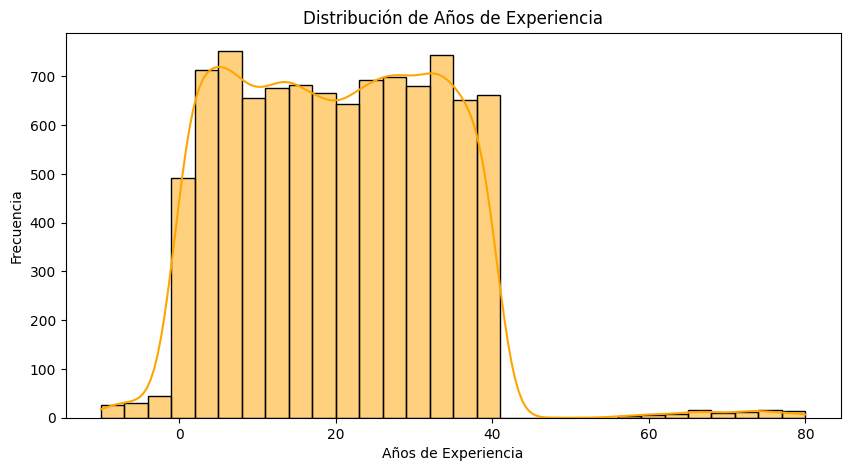

In [25]:
# 2. Distribución de la Experiencia
plt.figure(figsize=(10, 5))
sns.histplot(pd.to_numeric(df['experience'], errors='coerce'), bins=30, kde=True, color='orange')
plt.title('Distribución de Años de Experiencia')
plt.xlabel('Años de Experiencia')
plt.ylabel('Frecuencia')
plt.show()

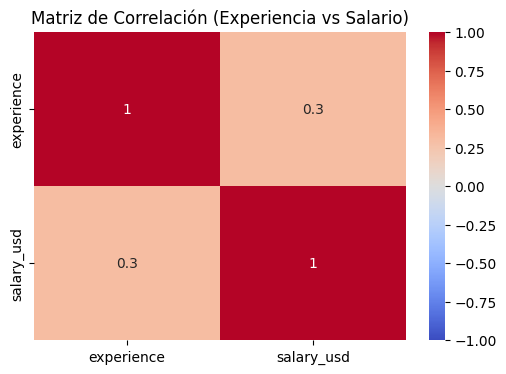

In [26]:
# 3. Correlación entre variables salario y experiencia
plt.figure(figsize=(6, 4))
df_num = pd.DataFrame()
for col in columnas_numericas:
    df_num[col] = pd.to_numeric(df[col], errors='coerce')
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Experiencia vs Salario)')
plt.show()

# 2. Limpieza de Datos

## 2.2 Copia de trabajo para no modificar el DataFrame original

In [27]:
df_clean = df.copy()
print("Shape original:", df.shape)
print("Shape copia de trabajo:", df_clean.shape)

Shape original: (10300, 7)
Shape copia de trabajo: (10300, 7)


## 2.3 Funciones auxiliares de limpieza

### 2.3.1 Función para normalizar listas separadas por coma

In [28]:
def normalizar_lista_tecnologias(valor):
    if pd.isna(valor):
        return np.nan

    tokens = [x.strip() for x in str(valor).split(",") if x.strip() != ""]

    if len(tokens) == 0:
        return np.nan

    # Eliminar repetidos internos y ordenar para estandarizar
    tokens_unicos = sorted(set(tokens), key=str.lower)

    return ", ".join(tokens_unicos)

### 2.3.2 Función para normalizar países

In [29]:
def normalizar_country(valor):
    if pd.isna(valor):
        return np.nan

    v = str(valor).strip().upper().replace('.', '')

    mapa_paises = {
        # USA
        "USA": "USA",
        "US": "USA",
        "UNITED STATES": "USA",
        "UNITED STATES OF AMERICA": "USA",
        "USA": "USA",

        # UK
        "UK": "UK",
        "GB": "UK",
        "GREAT BRITAIN": "UK",
        "UNITED KINGDOM": "UK",

        # Germany
        "GERMANY": "Germany",
        "DE": "Germany",
        "DEUTSCHLAND": "Germany",

        # Otros
        "FRANCE": "France",
        "FR": "France",

        "JAPAN": "Japan",
        "JP": "Japan",

        "INDIA": "India",
        "IN": "India",

        "BRAZIL": "Brazil",
        "BR": "Brazil",

        "CANADA": "Canada",
        "CA": "Canada",

        "AUSTRALIA": "Australia",
        "AU": "Australia",

        "SINGAPORE": "Singapore",
        "SG": "Singapore"
    }

    return mapa_paises.get(v, str(valor).strip().title())

### 2.3.3 Función para normalizar educación

In [30]:
def normalizar_education(valor):
    if pd.isna(valor):
        return np.nan

    v = str(valor).strip().upper().replace('.', '').replace("'", "")

    mapa_education = {
        "HIGH SCHOOL": "High School",
        "HIGHSCHOOL": "High School",
        "SECONDARY": "High School",

        "SOME COLLEGE": "Some College",
        "SOMECOLLEGE": "Some College",
        "INCOMPLETE": "Some College",

        "BACHELORS": "Bachelors",
        "BACHELOR": "Bachelors",

        "MASTERS": "Masters",
        "MASTER": "Masters",

        "PHD": "PhD",
        "DOCTORATE": "PhD"
    }

    return mapa_education.get(v, str(valor).strip().title())

### 2.3.4 Función para resumir outliers con IQR

In [31]:
def resumen_outliers_iqr(df, columna):
    serie = pd.to_numeric(df[columna], errors="coerce").dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outliers = (serie < limite_inferior) | (serie > limite_superior)
    cantidad_outliers = mascara_outliers.sum()

    return {
        "columna": columna,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": int(cantidad_outliers)
    }

### 2.3.5 Función para aplicar capping con IQR

In [32]:
def cap_outliers_iqr(serie):
    serie = pd.to_numeric(serie, errors="coerce")

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    serie_cap = serie.clip(lower=limite_inferior, upper=limite_superior)

    return serie_cap, limite_inferior, limite_superior

## 2.4 Unificación de nulos y pseudonulos

Antes de imputar o eliminar datos, primero hay que convertir todos los valores que significan “faltante” a un único formato (`NaN`).

Entre ellos se observaron casos como:

- `missing`
- `null`
- `NaN`
- `N/A`
- `n/a`
- `unknown`
- `?`
- celdas vacías

In [33]:
nulos_antes = df_clean.isnull().sum()

# Lista de pseudonulos a unificar
pseudonulos = [
    "missing", "Missing",
    "null", "NULL",
    "NaN", "nan",
    "N/A", "n/a",
    "NA", "na",
    "unknown", "Unknown",
    "?", "-", ""
]

df_clean = df_clean.replace(pseudonulos, np.nan)

In [34]:
# Conteo posterior
nulos_despues_unificacion = df_clean.isnull().sum()

comparacion_nulos = pd.DataFrame({
    "nulos_antes": nulos_antes,
    "nulos_despues_unificacion": nulos_despues_unificacion,
    "incremento": nulos_despues_unificacion - nulos_antes
})

print("Comparación de nulos antes y después de unificar pseudonulos:")
display(comparacion_nulos)

Comparación de nulos antes y después de unificar pseudonulos:


,nulos_antes,nulos_despues_unificacion,incremento
experience,624,709,85
country,0,0,0
education,826,826,0
languages,833,833,0
frameworks,823,823,0
company_size,0,0,0
salary_usd,630,713,83


## 2.5 Normalización de variables categóricas

### 2.5.1 Normalizar `country` y `education`

In [35]:
df_clean["country"] = df_clean["country"].apply(normalizar_country)
df_clean["education"] = df_clean["education"].apply(normalizar_education)

print("Valores únicos de country después de normalizar:")
print(sorted(df_clean["country"].dropna().unique())[:20])

print("\nValores únicos de education después de normalizar:")
print(sorted(df_clean["education"].dropna().unique()))

Valores únicos de country después de normalizar:
['Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Japan', 'Singapore', 'UK', 'USA']

Valores únicos de education después de normalizar:
['Bachelors', 'High School', 'Masters', 'PhD', 'Some College']


### 2.5.2 Normalizar `languages` y `frameworks`

In [36]:
df_clean["languages"] = df_clean["languages"].apply(normalizar_lista_tecnologias)
df_clean["frameworks"] = df_clean["frameworks"].apply(normalizar_lista_tecnologias)

print("Ejemplo de values_counts en languages:")
display(df_clean["languages"].value_counts(dropna=False).head(10))

print("\nEjemplo de values_counts en frameworks:")
display(df_clean["frameworks"].value_counts(dropna=False).head(10))

Ejemplo de values_counts en languages:


,count
languages,
NaN,833
"C++, Ruby",214
"Go, Swift",207
"Ruby, Rust",207
"C#, C++",204
"PHP, Python",202
"JavaScript, Ruby",200
"JavaScript, PHP",199
"C++, Swift",198



Ejemplo de values_counts en frameworks:


,count
frameworks,
NaN,823
"Django, Spring",229
"ASP.NET, Spring",224
"Angular, Express",212
"Laravel, Ruby on Rails",211
"Ruby on Rails, Spring",207
"Django, Laravel",202
"Angular, Laravel",201
"Django, React",200


### 2.5.3 Limpieza de `company_size`

In [37]:
df_clean["company_size"] = df_clean["company_size"].astype(str).str.strip()
df_clean["company_size"] = df_clean["company_size"].replace("nan", np.nan)

print("Valores únicos de company_size:")
print(sorted(df_clean["company_size"].dropna().unique()))

Valores únicos de company_size:
['1-10', '1001-5000', '11-50', '201-1000', '5000+', '51-200']


## 2.6 Conversión de tipos de datos

In [38]:
#Las columnas `experience` y `salary_usd` deben ser numéricas para poder analizar nulos, outliers y estadísticas de manera correcta.
df_clean["experience"] = pd.to_numeric(df_clean["experience"], errors="coerce")
df_clean["salary_usd"] = pd.to_numeric(df_clean["salary_usd"], errors="coerce")

print("Tipos de datos después de convertir experience y salary_usd:")
print(df_clean.dtypes)

Tipos de datos después de convertir experience y salary_usd:
experience      float64
country          object
education        object
languages        object
frameworks       object
company_size     object
salary_usd      float64
dtype: object


## 2.7 Tratamiento de valores imposibles en variables numéricas


### Reglas aplicadas

- `experience < 0`  → inválido
- `experience > 50` → inválido
- `salary_usd <= 0` → inválido

In [39]:
exp_invalidas = ((df_clean["experience"] < 0) | (df_clean["experience"] > 50)).sum()
salary_invalidos = (df_clean["salary_usd"] <= 0).sum()

print("Cantidad de experiencias inválidas detectadas:", int(exp_invalidas))
print("Cantidad de salarios inválidos detectados:", int(salary_invalidos))

# Reemplazo por NaN
df_clean.loc[(df_clean["experience"] < 0) | (df_clean["experience"] > 50), "experience"] = np.nan
df_clean.loc[df_clean["salary_usd"] <= 0, "salary_usd"] = np.nan

print("\nNulos después de invalidar valores imposibles:")
print(df_clean[["experience", "salary_usd"]].isnull().sum())

Cantidad de experiencias inválidas detectadas: 195
Cantidad de salarios inválidos detectados: 97

Nulos después de invalidar valores imposibles:
experience    904
salary_usd    810
dtype: int64


## 2.8 Eliminación de duplicados

In [40]:
duplicados_antes = df_clean.duplicated().sum()
print("Duplicados detectados antes de eliminar:", duplicados_antes)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

duplicados_despues = df_clean.duplicated().sum()
print("Duplicados después de eliminar:", duplicados_despues)
print("Nuevo shape:", df_clean.shape)

Duplicados detectados antes de eliminar: 256
Duplicados después de eliminar: 0
Nuevo shape: (10044, 7)


## 2.9 Manejo de valores nulos

### Decisiones adoptadas

- `salary_usd`: eliminar filas con nulo porque es la variable principal del análisis
- `experience`: imputar con mediana
- `country`, `education`, `languages`, `frameworks`, `company_size`: completar con `Unknown`

In [41]:
print("Nulos antes del tratamiento final:")
display(df_clean.isnull().sum())

Nulos antes del tratamiento final:


,0
experience,885
country,0
education,804
languages,807
frameworks,800
company_size,0
salary_usd,795


### 2.9.1 Eliminar filas sin salario

In [42]:
filas_antes = df_clean.shape[0]

df_clean = df_clean.dropna(subset=["salary_usd"]).copy()

filas_despues = df_clean.shape[0]
filas_eliminadas = filas_antes - filas_despues

print("Filas eliminadas por salary_usd nulo:", filas_eliminadas)
print("Shape después de eliminar salary_usd nulo:", df_clean.shape)

Filas eliminadas por salary_usd nulo: 795
Shape después de eliminar salary_usd nulo: (9249, 7)


### 2.9.2 Imputar `experience` con mediana

In [43]:
mediana_experience = df_clean["experience"].median()
print("Mediana de experience:", mediana_experience)

df_clean["experience"] = df_clean["experience"].fillna(mediana_experience)
df_clean["experience"] = df_clean["experience"].round().astype("Int64")

print("Nulos en experience después de imputar:", df_clean["experience"].isnull().sum())
print("Tipo final de experience:", df_clean["experience"].dtype)

Mediana de experience: 20.0
Nulos en experience después de imputar: 0
Tipo final de experience: Int64


### 2.9.3 Imputar categóricas con `Unknown`


In [44]:
columnas_categoricas = ["country", "education", "languages", "frameworks", "company_size"]

for col in columnas_categoricas:
    df_clean[col] = df_clean[col].fillna("Unknown")

print("Nulos después de completar categóricas:")
display(df_clean[columnas_categoricas].isnull().sum())

Nulos después de completar categóricas:


,0
country,0
education,0
languages,0
frameworks,0
company_size,0


## 2.10 Tratamiento de outliers

### 2.10.1 Revisar outliers de salario antes del capping

In [45]:
#Se aplicará la técnica de **capping con IQR** para `salary_usd`

resumen_salary_antes = resumen_outliers_iqr(df_clean, "salary_usd")

print("Resumen de outliers en salary_usd antes del capping:")
for k, v in resumen_salary_antes.items():
    print(f"{k}: {v}")

Resumen de outliers en salary_usd antes del capping:
columna: salary_usd
q1: 98034.0
q3: 165286.0
iqr: 67252.0
limite_inferior: -2844.0
limite_superior: 266164.0
cantidad_outliers: 99


### 2.10.2 Aplicar capping a `salary_usd`

In [46]:
# copia para comparación
df_clean["salary_usd_before_cap"] = df_clean["salary_usd"].copy()

# Aplicar capping
df_clean["salary_usd"], lim_inf_salary, lim_sup_salary = cap_outliers_iqr(df_clean["salary_usd"])

print("Límite inferior aplicado:", lim_inf_salary)
print("Límite superior aplicado:", lim_sup_salary)

Límite inferior aplicado: -2844.0
Límite superior aplicado: 266164.0


### 2.10.3 Verificar outliers de salario después del capping

In [47]:
resumen_salary_despues = resumen_outliers_iqr(df_clean, "salary_usd")

print("Resumen de outliers en salary_usd después del capping:")
for k, v in resumen_salary_despues.items():
    print(f"{k}: {v}")

Resumen de outliers en salary_usd después del capping:
columna: salary_usd
q1: 98034.0
q3: 165286.0
iqr: 67252.0
limite_inferior: -2844.0
limite_superior: 266164.0
cantidad_outliers: 0


## 2.11 Validación antes vs después

In [48]:
#se comparará el estado del dataset original contra el dataset limpio.
resumen_comparativo = pd.DataFrame({
    "dataset": ["Original", "Limpio"],
    "filas": [df.shape[0], df_clean.shape[0]],
    "columnas": [df.shape[1], df_clean.shape[1]],
    "duplicados": [df.duplicated().sum(), df_clean.duplicated().sum()],
    "nulos_experience": [df["experience"].isnull().sum(), df_clean["experience"].isnull().sum()],
    "nulos_salary_usd": [df["salary_usd"].isnull().sum(), df_clean["salary_usd"].isnull().sum()]
})

display(resumen_comparativo)

,dataset,filas,columnas,duplicados,nulos_experience,nulos_salary_usd
0,Original,10300,7,211,624,630
1,Limpio,9249,8,1,0,0


## 2.12 Revisión final de nulos y tipos

In [49]:
print("Nulos finales por columna:")
display(df_clean.isnull().sum())

Nulos finales por columna:


,0
experience,0
country,0
education,0
languages,0
frameworks,0
company_size,0
salary_usd,0
salary_usd_before_cap,0


In [50]:
print("\nTipos de datos finales:")
print(df_clean.dtypes)


Tipos de datos finales:
experience                 Int64
country                   object
education                 object
languages                 object
frameworks                object
company_size              object
salary_usd               float64
salary_usd_before_cap    float64
dtype: object


In [51]:
print("\nVista previa del dataset limpio:")
display(df_clean.head())


Vista previa del dataset limpio:


,experience,country,education,languages,frameworks,company_size,salary_usd,salary_usd_before_cap
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189.0,122189.0
1,38,France,Masters,"Python, Ruby",Unknown,201-1000,147754.0,147754.0
2,36,USA,Some College,"C++, PHP","Ruby on Rails, Spring",5000+,220819.0,220819.0
3,3,India,Masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943.0,31943.0
4,18,USA,Masters,"Go, Java","Django, React",5000+,166442.0,166442.0


## 2.13 Visualización antes y después del tratamiento de outliers

### 2.13.1 Boxplot de salario antes y después

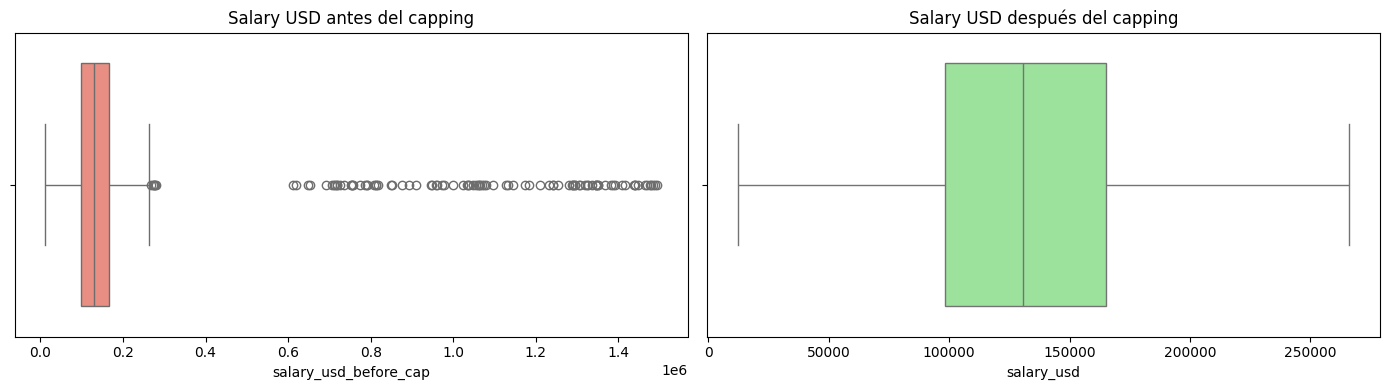

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=df_clean["salary_usd_before_cap"], ax=axes[0], color="salmon")
axes[0].set_title("Salary USD antes del capping")

sns.boxplot(x=df_clean["salary_usd"], ax=axes[1], color="lightgreen")
axes[1].set_title("Salary USD después del capping")

plt.tight_layout()
plt.show()

#3  Feature Engineering en variables multivaluadas



In [53]:
df_clean['num_languages'] = df_clean['languages'].apply(lambda x: len([i.strip() for i in str(x).split(',')]))
df_clean['num_frameworks'] = df_clean['frameworks'].apply(lambda x: len([i.strip() for i in str(x).split(',')]))

In [54]:
display(df_clean)

,experience,country,education,languages,frameworks,company_size,salary_usd,salary_usd_before_cap,num_languages,num_frameworks
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189.0,122189.0,2,2
1,38,France,Masters,"Python, Ruby",Unknown,201-1000,147754.0,147754.0,2,1
2,36,USA,Some College,"C++, PHP","Ruby on Rails, Spring",5000+,220819.0,220819.0,2,2
3,3,India,Masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943.0,31943.0,2,2
4,18,USA,Masters,"Go, Java","Django, React",5000+,166442.0,166442.0,2,2
...,...,...,...,...,...,...,...,...,...,...
10039,20,France,Bachelors,"Go, Rust","Angular, Express",1-10,154727.0,154727.0,2,2
10040,5,Japan,Masters,Unknown,"Laravel, Vue",1001-5000,69876.0,69876.0,1,2
10041,21,USA,Unknown,"Python, Swift","Django, Express",11-50,154794.0,154794.0,2,2
10042,37,USA,Masters,"C#, Swift","Angular, Laravel",51-200,178945.0,178945.0,2,2


# FASE 2 - Transformación de Datos y Pipeline

En esta sección se realiza la transformación del dataset limpio, incluyendo:
- Escalado de variables numéricas
- Codificación de variables categóricas
- Construcción de un pipeline para automatizar el proceso

#Imports necesarios

In [55]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Petición del dataset LIMPIO al repositorio en github y su visualización

In [56]:
url = "https://raw.githubusercontent.com/Nicossm/parcial1/main/data/processed/clean.csv"
df2 = pd.read_csv(url)

df2.head(5)

,experience,country,education,languages,frameworks,company_size,salary_usd,num_languages,num_frameworks,salary_usd_before_cap
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189.0,2,2,122189.0
1,38,France,Masters,"Python, Ruby",Unknown,201-1000,147754.0,2,1,147754.0
2,36,USA,Some College,"C++, PHP","Ruby on Rails, Spring",5000+,220819.0,2,2,220819.0
3,3,India,Masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943.0,2,2,31943.0
4,18,USA,Masters,"Go, Java","Django, React",5000+,166442.0,2,2,166442.0


## 2. Separación de variables objetivo y predictoras

Se define la variable objetivo (`salary_usd`) y las variables predictoras.
También se eliminan variables no útiles o redundantes.

In [57]:
y = df2['salary_usd']


X = df2.drop(columns=[
    'salary_usd',
    'salary_usd_before_cap',
    'languages',
    'frameworks'
])

## 3. Clasificación de variables

Se separan variables numéricas y categóricas para aplicar transformaciones adecuadas.

In [58]:
num_cols = ['experience', 'num_languages', 'num_frameworks']
cat_cols = ['country', 'education', 'company_size']

## 4. Construcción del pipeline

Se aplica:
- Estandarización a variables numéricas
- OneHotEncoding a variables categóricas

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

## 5. Aplicación de transformaciones

Se ajusta el pipeline y se transforma el dataset a formato numérico.

In [60]:
X_transformed = pipeline.fit_transform(X)

## 6. Reconstrucción del dataset procesado

Se reconstruye el dataset con nombres de variables para mejorar la interpretabilidad.

In [61]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

X_transformed_df = pd.DataFrame(
    X_transformed.toarray(),
    columns=feature_names
)

## 7. Limpieza de nombres de columnas

Se eliminan prefijos para mejorar la lectura del dataset final.

In [62]:
X_transformed_df.columns = [
    col.replace("num__", "").replace("cat__", "")
    for col in X_transformed_df.columns
]

## 8. Reincorporación de la variable objetivo

La variable objetivo (`salary_usd`) se agrega nuevamente al dataset transformado para permitir análisis y visualización en etapas posteriores.

In [63]:
X_transformed_df['salary_usd'] = y.values

## 9. Exportación del dataset procesado

Se guarda el dataset final para uso en etapas posteriores del proyecto.

In [64]:
import os

os.makedirs("data/processed", exist_ok=True)

X_transformed_df.to_csv("data/processed/transformed.csv", index=False)

In [65]:
X_transformed_df.head()

,experience,num_languages,num_frameworks,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,...,education_PhD,education_Some College,education_Unknown,company_size_1-10,company_size_1001-5000,company_size_11-50,company_size_201-1000,company_size_5000+,company_size_51-200,salary_usd
0,0.362418,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,122189.0
1,1.596651,0.462191,-2.198939,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,147754.0
2,1.420332,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,220819.0
3,-1.488932,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,31943.0
4,-0.166539,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,166442.0


# FASE 3


Esta fase recibe el dataset ya transformado y realiza:
1. Feature Engineering: creación de variables nuevas
2. Visualización exploratoria (EDA) con insights

## 1. Importación de librerías

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del dataset transformado

Se carga el dataset procesado por el Integrante 2, disponible en `/data/transformed` del repositorio.

In [67]:
# Cargar el dataset transformado desde GitHub
url = "https://raw.githubusercontent.com/Nicossm/parcial1/main/data/transformed/transformed.csv"
df3 = pd.read_csv(url)

print("Shape del dataset transformado:", df3.shape)
df3.head()

Shape del dataset transformado: (9249, 26)


,experience,num_languages,num_frameworks,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,...,education_PhD,education_Some College,education_Unknown,company_size_1-10,company_size_1001-5000,company_size_11-50,company_size_201-1000,company_size_5000+,company_size_51-200,salary_usd
0,0.362418,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,122189.0
1,1.596651,0.462191,-2.198939,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,147754.0
2,1.420332,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,220819.0
3,-1.488932,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,31943.0
4,-0.166539,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,166442.0


In [68]:
# Revisión general del dataset
df3.describe()

,experience,num_languages,num_frameworks,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,...,education_PhD,education_Some College,education_Unknown,company_size_1-10,company_size_1001-5000,company_size_11-50,company_size_201-1000,company_size_5000+,company_size_51-200,salary_usd
count,9.249000e+03,9.249000e+03,9.249000e+03,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,...,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000
mean,9.410908e-17,1.407795e-16,1.092818e-16,0.050924,0.025516,0.093091,0.050600,0.104119,0.103254,0.052006,...,0.042815,0.090604,0.080874,0.168018,0.163477,0.172992,0.164018,0.167153,0.164342,132629.170829
std,1.000054e+00,1.000054e+00,1.000054e+00,0.219855,0.157696,0.290576,0.219191,0.305432,0.304307,0.222050,...,0.202452,0.287061,0.272656,0.373903,0.369820,0.378261,0.370312,0.373133,0.370606,48244.259922
min,-1.753410e+00,-2.163609e+00,-2.198939e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12259.000000
25%,-7.836559e-01,4.621907e-01,4.547648e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98034.000000
50%,9.779614e-03,4.621907e-01,4.547648e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,130548.000000
75%,8.032151e-01,4.621907e-01,4.547648e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,165286.000000
max,1.772970e+00,4.621907e-01,4.547648e-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,266164.000000


## 3. Feature Engineering

En esta sección se crean 3 variables nuevas a partir de los datos transformados que ya tenemos.
Como ya se aplicó OneHotEncoding, las columnas de texto ya no existen como tal,
sino que hay columnas como `education_Masters`, `education_PhD`, `country_USA`, etc.

### 3.1 `is_high_education` — ¿Tiene educación avanzada?

Se crea una variable binaria (0 o 1) que indica si el desarrollador tiene Masters o PhD.
Esto resume la información de dos columnas OHE en una sola variable más interpretable.

In [69]:
# 1 si tiene Masters o PhD, 0 si no
df3['is_high_education'] = ((df3['education_Masters'] == 1.0) | (df3['education_PhD'] == 1.0)).astype(int)

print("Distribución de is_high_education:")
print(df3['is_high_education'].value_counts())

Distribución de is_high_education:
is_high_education
0    6317
1    2932
Name: count, dtype: int64


### 3.2 `is_big_company` — ¿Trabaja en empresa grande?

Variable binaria que vale 1 si el desarrollador trabaja en una empresa con más de 1000 empleados.
La hipótesis es que las empresas grandes tienden a pagar mejores salarios.

In [70]:
# 1 si la empresa tiene más de 1000 empleados
df3['is_big_company'] = ((df3['company_size_1001-5000'] == 1.0) | (df3['company_size_5000+'] == 1.0)).astype(int)

print("Distribución de is_big_company:")
print(df3['is_big_company'].value_counts())

Distribución de is_big_company:
is_big_company
0    6191
1    3058
Name: count, dtype: int64


### 3.3 `exp_edu_score` — Score combinado de experiencia y educación

Se crea un score que combina la experiencia estandarizada con un bonus si tiene educación avanzada.
La idea es que un desarrollador con más experiencia Y mayor educación debería tener un salario más alto.
Se verifica que este score tiene mejor correlación con el salario que la experiencia sola.

In [71]:
# Score combinado: experiencia estandarizada + bonus por educación avanzada
df3['exp_edu_score'] = df3['experience'] + df3['is_high_education'] * 0.5

# Comparar correlaciones con el salario
print("Correlación de 'experience' con salary_usd:   ", round(df3['experience'].corr(df3['salary_usd']), 4))
print("Correlación de 'exp_edu_score' con salary_usd:", round(df3['exp_edu_score'].corr(df3['salary_usd']), 4))

Correlación de 'experience' con salary_usd:    0.7078
Correlación de 'exp_edu_score' con salary_usd: 0.7111


In [72]:
# Vista del dataset con las nuevas columnas creadas
df3[['experience', 'is_high_education', 'is_big_company', 'exp_edu_score', 'salary_usd']].head(8)

,experience,is_high_education,is_big_company,exp_edu_score,salary_usd
0,0.362418,0,1,0.362418,122189.0
1,1.596651,1,0,2.096651,147754.0
2,1.420332,0,1,1.420332,220819.0
3,-1.488932,1,0,-0.988932,31943.0
4,-0.166539,1,1,0.333461,166442.0
5,0.362418,0,0,0.362418,121414.0
6,-1.488932,0,0,-1.488932,79820.0
7,0.538737,1,1,1.038737,170805.0


## 4. Visualización — EDA

Se generan 4 gráficos para explorar las relaciones entre las variables y el salario.

### Gráfico 1 — Distribución del salario

Antes de comparar variables, revisamos cómo se distribuye la variable objetivo `salary_usd`.

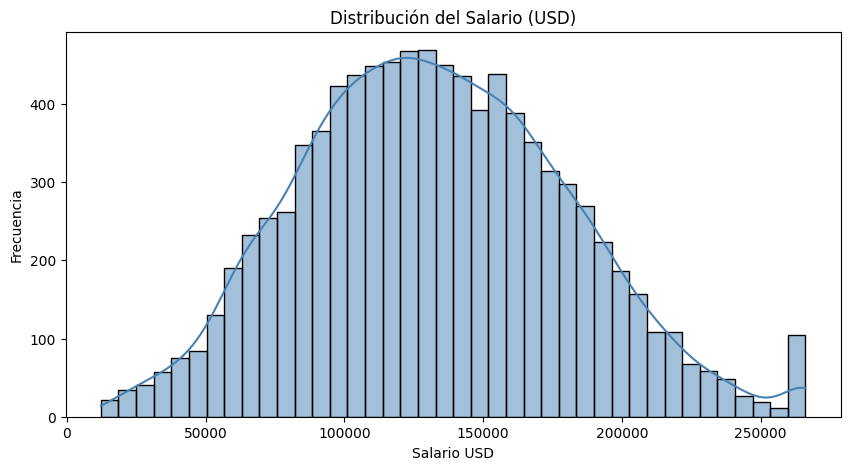

In [73]:
# Distribución del salario
plt.figure(figsize=(10, 5))
sns.histplot(df3['salary_usd'], bins=40, kde=True, color='steelblue')
plt.title('Distribución del Salario (USD)')
plt.xlabel('Salario USD')
plt.ylabel('Frecuencia')
plt.show()

**Insight Gráfico 1:**  
El salario sigue una distribución aproximadamente normal, con la mayoría de los desarrolladores ganando entre 80.000 y 180.000 USD. La curva KDE confirma que no hay una asimetría fuerte, lo que es un buen indicador de que el capping de outliers que realizó el Integrante 1 funcionó correctamente.

### Gráfico 2 — Experiencia estandarizada vs Salario

Se visualiza la relación directa entre experiencia y salario.

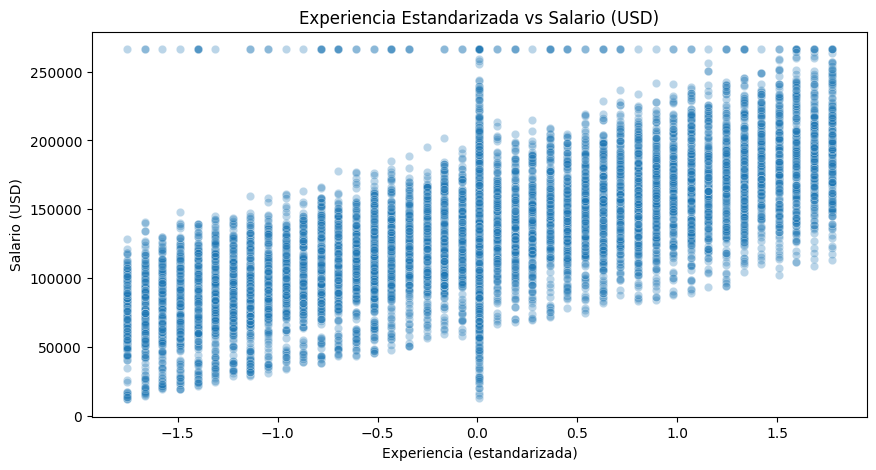

ValueError: could not convert string to float: '?'

In [74]:
# Scatter de experiencia vs salario
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df3, x='experience', y='salary_usd', alpha=0.3)
plt.title('Experiencia Estandarizada vs Salario (USD)')
plt.xlabel('Experiencia (estandarizada)')
plt.ylabel('Salario (USD)')
plt.show()

print("Correlación Pearson (experience vs salary_usd):", round(df['experience'].corr(df3['salary_usd']), 4))

**Insight Gráfico 2:**  
Se observa una tendencia positiva clara: a mayor experiencia estandarizada, mayor salario. La correlación de Pearson confirma esta relación. Sin embargo, existe bastante dispersión, lo que indica que la experiencia sola no explica todo el salario y que otras variables como el país o la educación también influyen.

### Gráfico 3 — Salario según nivel de educación avanzada

Se compara el salario entre desarrolladores con y sin educación avanzada (Masters o PhD).

In [ ]:
# Boxplot de salario por nivel educativo
plt.figure(figsize=(8, 5))
sns.boxplot(data=df3, x='is_high_education', y='salary_usd', palette='pastel')
plt.title('Salario según Educación Avanzada')
plt.xlabel('Tiene educación avanzada (0 = No, 1 = Sí)')
plt.ylabel('Salario (USD)')
plt.show()

# Salario promedio por grupo
print("Salario promedio por grupo:")
print(df3.groupby('is_high_education')['salary_usd'].mean().round(0))

**Insight Gráfico 3:**  
Los desarrolladores con Masters o PhD (valor 1) tienen una mediana de salario más alta que quienes no tienen ese nivel educativo. La caja del grupo 1 está desplazada hacia arriba, confirmando que la educación avanzada está asociada a mayores ingresos en este dataset.

### Gráfico 4 — Matriz de correlación de las variables numéricas

Se usa un heatmap para visualizar qué tan relacionadas están las variables numéricas entre sí.

In [ ]:
# Seleccionar variables numéricas relevantes para la correlación
cols_corr = ['experience', 'num_languages', 'num_frameworks',
             'is_high_education', 'is_big_company', 'exp_edu_score', 'salary_usd']

plt.figure(figsize=(9, 6))
sns.heatmap(df3[cols_corr].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlación de Variables Clave')
plt.tight_layout()
plt.show()

**Insight Gráfico 4:**  
El heatmap muestra que `exp_edu_score` tiene la correlación más alta con `salary_usd` de todas las variables numéricas, lo que valida la utilidad del feature que creamos. También se observa que `num_languages` y `num_frameworks` tienen correlación muy baja con el salario, lo que sugiere que saber más tecnologías no necesariamente se traduce en mayor sueldo.

In [ ]:
from google.colab import files

# Guardar y descargar
df3.to_csv('featured.csv', index=False)
files.download('featured.csv')